# Fatalities_Isreal_Palestine_conflict_2000_to_2023
### Data Analyst: Monsurat Olayinka Onashokun


# 📌 Conflict Intensity Analysis

## Objective

Analyze how conflict intensity evolves over time and identify key trends and structural changes.

## Approach

The analysis includes data cleaning, exploratory analysis, and trend evaluation using time-based techniques.

## Focus

This notebook emphasizes data-driven insights, while a separate PowerPoint presents the key findings in a business context.


## 📦 Import Libraries



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#   📁 Load the dataset
df = pd.read_csv('../data//isr_pse_conflict.csv')

# Initial look at the data
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 11124 entries, 0 to 11123
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          11124 non-null  str    
 1   date_of_event                 11124 non-null  str    
 2   age                           10995 non-null  float64
 3   citizenship                   11124 non-null  str    
 4   event_location                11124 non-null  str    
 5   event_location_district       11124 non-null  str    
 6   event_location_region         11124 non-null  str    
 7   date_of_death                 11124 non-null  str    
 8   gender                        11104 non-null  str    
 9   took_part_in_the_hostilities  9694 non-null   str    
 10  place_of_residence            11056 non-null  str    
 11  place_of_residence_district   11056 non-null  str    
 12  type_of_injury                10833 non-null  str    
 13  ammunition  

,name,date_of_event,age,citizenship,event_location,event_location_district,event_location_region,date_of_death,gender,took_part_in_the_hostilities,place_of_residence,place_of_residence_district,type_of_injury,ammunition,killed_by,notes
0,'Abd a-Rahman Suleiman Muhammad Abu Daghash,2023-09-24,32.0,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,Fatally shot by Israeli forces while standing ...
1,Usayed Farhan Muhammad 'Ali Abu 'Ali,2023-09-24,21.0,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,Fatally shot by Israeli forces while trying to...
2,'Abdallah 'Imad Sa'ed Abu Hassan,2023-09-22,16.0,Palestinian,Kfar Dan,Jenin,West Bank,2023-09-22,M,NaN,al-Yamun,Jenin,gunfire,live ammunition,Israeli security forces,Fatally shot by soldiers while firing at them ...
3,Durgham Muhammad Yihya al-Akhras,2023-09-20,19.0,Palestinian,'Aqbat Jaber R.C.,Jericho,West Bank,2023-09-20,M,NaN,'Aqbat Jaber R.C.,Jericho,gunfire,live ammunition,Israeli security forces,Shot in the head by Israeli forces while throw...
4,Raafat 'Omar Ahmad Khamaisah,2023-09-19,15.0,Palestinian,Jenin R.C.,Jenin,West Bank,2023-09-19,M,NaN,Jenin,Jenin,gunfire,live ammunition,Israeli security forces,Wounded by soldiers’ gunfire after running awa...


## Overview of the Structure

In [2]:
# 📊 Data Overview

## 🔍 Structure of the Dataset

df.info()

## 📈 Summary Statistics

df.describe()

## ❗ Missing Values

df.isnull().sum()

## 🔑 Unique Values (Key Columns)




## 📌 Initial Observations

## The dataset contains both numerical and categorical variables
## Some columns include missing values that will require cleaning
## The time range appears to cover multiple years, enabling trend analysis
## Key variables such as intensity and events will be central to the analysis


<class 'pandas.DataFrame'>
RangeIndex: 11124 entries, 0 to 11123
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          11124 non-null  str    
 1   date_of_event                 11124 non-null  str    
 2   age                           10995 non-null  float64
 3   citizenship                   11124 non-null  str    
 4   event_location                11124 non-null  str    
 5   event_location_district       11124 non-null  str    
 6   event_location_region         11124 non-null  str    
 7   date_of_death                 11124 non-null  str    
 8   gender                        11104 non-null  str    
 9   took_part_in_the_hostilities  9694 non-null   str    
 10  place_of_residence            11056 non-null  str    
 11  place_of_residence_district   11056 non-null  str    
 12  type_of_injury                10833 non-null  str    
 13  ammunition  

name                               0
date_of_event                      0
age                              129
citizenship                        0
event_location                     0
event_location_district            0
event_location_region              0
date_of_death                      0
gender                            20
took_part_in_the_hostilities    1430
place_of_residence                68
place_of_residence_district       68
type_of_injury                   291
ammunition                      5253
killed_by                          0
notes                            280
dtype: int64

In [3]:
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: Index(['age'], dtype='str')
Categorical: Index(['name', 'date_of_event', 'citizenship', 'event_location',
       'event_location_district', 'event_location_region', 'date_of_death',
       'gender', 'took_part_in_the_hostilities', 'place_of_residence',
       'place_of_residence_district', 'type_of_injury', 'ammunition',
       'killed_by', 'notes'],
      dtype='str')


## EDA + Data Cleaning

In [4]:
# Analysis of the 'name' column
print(f"Data Type: {df['name'].dtype}")
print(f"Total entries: {len(df['name'])}")
print(f"Unique names: {df['name'].nunique()}")
print(f"Missing values: {df['name'].isnull().sum()}")

# Professional check: Why are there fewer unique names than total rows?
duplicates = df[df.duplicated(subset=['name'], keep=False)].sort_values('name')
print("\nExample of repeated names (first 4 rows):")
print(duplicates[['name', 'date_of_event', 'age']].head(4))

## Observation: We have $11,124$ rows but only $11,083$ unique names.Interpretation: This is likely not an error; 
# it's common for different people to share the same name (like "Muhammad al-Najjar"). 
# In a professional report, 
# you should mention that the name column serves as a unique identifier per event but isn't a "Primary Key.

Data Type: str
Total entries: 11124
Unique names: 11083
Missing values: 0

Example of repeated names (first 4 rows):
                             name date_of_event   age
6678     'Ali Ahmad 'Ali al-'Aidy    2007-06-30  18.0
8250     'Ali Ahmad 'Ali al-'Aidy    2004-06-30  15.0
7263  Ahmad Muhammad Ahmad Shahin    2006-07-11  29.0
7135  Ahmad Muhammad Ahmad Shahin    2006-08-04  25.0


## Fixing

In [5]:
#  RENAME CRASHING COLUMN 
df = df.rename(columns={'took_part_in_the_hostilities': 'hostility_status'})

# --- FIX B: REPAIR AGE DATA TYPE ---
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'] = df['age'].fillna(df['age'].median()).astype(int)

# Convert date and extract year
df['date_of_event'] = pd.to_datetime(df['date_of_event'])
df['year'] = df['date_of_event'].dt.year

print("Foundational Fixes Complete:")
print(df[['age', 'hostility_status', 'year']].head())

Foundational Fixes Complete:
   age hostility_status  year
0   32              NaN  2023
1   21              NaN  2023
2   16              NaN  2023
3   19              NaN  2023
4   15              NaN  2023


In [6]:
# Fix: Remove exact duplicate rows
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)

print(f"Removed {initial_count - final_count} duplicate rows.")

Removed 7 duplicate rows.


In [7]:
# Fix: Fill missing categorical values with 'Unknown'
df['gender'] = df['gender'].fillna('Unknown')
df['type_of_injury'] = df['type_of_injury'].fillna('Unknown')

# Check if any nulls remain in these columns
print(df[['age', 'gender', 'type_of_injury']].isnull().sum())

age               0
gender            0
type_of_injury    0
dtype: int64


* The distribution of age initially contained 129 missing values ($NaN$). To maintain the integrity of the dataset, I applied Median Imputation. The charts above illustrate the shift: the right-hand plot shows a concentration at age 23, where the missing data was successfully integrated. This ensures that subsequent analyses, such as calculating the average age of victims, are based on the full population size*

## Feature Engineering

In [8]:


# Now apply the bins to the NUMERIC age column
age_bins = [0, 12, 17, 25, 45, 65, 120]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Middle-Aged', 'Senior']

# Ensure you are targeting 'age', NOT 'date_of_event'
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

print("Success! Age groups created.")

df

Success! Age groups created.


,name,date_of_event,age,citizenship,event_location,event_location_district,event_location_region,date_of_death,gender,hostility_status,place_of_residence,place_of_residence_district,type_of_injury,ammunition,killed_by,notes,year,age_group
0,'Abd a-Rahman Suleiman Muhammad Abu Daghash,2023-09-24,32,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,Fatally shot by Israeli forces while standing ...,2023,Adult
1,Usayed Farhan Muhammad 'Ali Abu 'Ali,2023-09-24,21,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,NaN,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,Fatally shot by Israeli forces while trying to...,2023,Young Adult
2,'Abdallah 'Imad Sa'ed Abu Hassan,2023-09-22,16,Palestinian,Kfar Dan,Jenin,West Bank,2023-09-22,M,NaN,al-Yamun,Jenin,gunfire,live ammunition,Israeli security forces,Fatally shot by soldiers while firing at them ...,2023,Teenager
3,Durgham Muhammad Yihya al-Akhras,2023-09-20,19,Palestinian,'Aqbat Jaber R.C.,Jericho,West Bank,2023-09-20,M,NaN,'Aqbat Jaber R.C.,Jericho,gunfire,live ammunition,Israeli security forces,Shot in the head by Israeli forces while throw...,2023,Young Adult
4,Raafat 'Omar Ahmad Khamaisah,2023-09-19,15,Palestinian,Jenin R.C.,Jenin,West Bank,2023-09-19,M,NaN,Jenin,Jenin,gunfire,live ammunition,Israeli security forces,Wounded by soldiers’ gunfire after running awa...,2023,Teenager
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11119,Binyamin Herling,2000-10-19,64,Israeli,Nablus,Nablus,West Bank,2000-10-19,M,Israelis,Kedumim,Tulkarm,gunfire,live ammunition,Palestinian civilians,Killed while hiking on Mt. Eival.,2000,Middle-Aged
11120,Farid Musa 'Issa a-Nesasreh,2000-10-17,28,Palestinian,Beit Furik,Nablus,West Bank,2000-10-17,M,Unknown,Beit Furik,Nablus,gunfire,NaN,Israeli civilians,Killed by a settler from Itamar while harvesti...,2000,Adult
11121,Hillel Lieberman,2000-10-07,36,Israeli,Nablus,Nablus,West Bank,2000-10-07,M,Israelis,Elon Moreh,Nablus,gunfire,live ammunition,Palestinian civilians,His body was found a day after he disappeared.,2000,Adult
11122,Fahed Mustafa 'Odeh Baker,2000-10-07,21,Palestinian,Bidya,Salfit,West Bank,2000-10-07,M,No,Bidya,Salfit,gunfire,NaN,Israeli civilians,Killed by settlers who rioted in Biddya village.,2000,Young Adult


In [9]:


# 1. Life Stage Binning
# We create categories based on social and biological development. 
# This is more meaningful than simple 10-year intervals.
life_stage_bins = [0, 12, 17, 25, 45, 65, 120]
life_stage_labels = ['Child (0-12)', 'Teenager (13-17)', 'Young Adult (18-25)', 'Adult (26-45)', 'Middle-Aged (46-65)', 'Senior (66+)']
df['life_stage'] = pd.cut(df['age'], bins=life_stage_bins, labels=life_stage_labels, right=True)

# 2. Generational Bins (Decades)
# Grouping by decade to identify wider generational patterns.
df['age_decade'] = (df['age'] // 10) * 10

# 3. Binary Vulnerability Indicators
# These flags make it easy to run statistics on specific sensitive groups.
df['is_minor'] = (df['age'] < 18).astype(int) 
df['is_senior'] = (df['age'] >= 65).astype(int)

# 4. Statistical Outlier Detection
# Identifying 'extreme' ages (Ages above 49 in this dataset). 
# This shows you have a mastery of data quality and descriptive statistics.
q3 = df['age'].quantile(0.75)
q1 = df['age'].quantile(0.25)
iqr = q3 - q1
upper_bound = q3 + (1.5 * iqr)
df['is_age_outlier'] = (df['age'] > upper_bound).astype(int)

# --- VERIFICATION ---
print("New Age Features Preview:")
print(df[['age', 'life_stage', 'age_decade', 'is_minor', 'is_age_outlier']].head())

New Age Features Preview:
   age           life_stage  age_decade  is_minor  is_age_outlier
0   32        Adult (26-45)          30         0               0
1   21  Young Adult (18-25)          20         0               0
2   16     Teenager (13-17)          10         1               0
3   19  Young Adult (18-25)          10         0               0
4   15     Teenager (13-17)          10         1               0


In [10]:
# ==========================================
#  FEATURE ENGINEERING: TYPE OF INJURY
# ==========================================

# 1. Cleaning: Fill missing values with 'Unknown'
# This ensures that our charts don't have gaps and accounts for every row.
df['type_of_injury'] = df['type_of_injury'].fillna('Unknown')

# 2. Engineering: Logic-Based Categorization
# We simplify the messy raw text into 7 clean, operational categories.
# This makes the data much easier to read in a report.
def categorize_injury(injury):
    injury = str(injury).lower()
    if 'gunfire' in injury: 
        return 'Firearms'
    elif 'explosion' in injury or 'shelling' in injury: 
        return 'Explosives/Artillery'
    elif 'stabbing' in injury: 
        return 'Stabbing'
    elif 'hit by a vehicle' in injury: 
        return 'Vehicle'
    elif 'beating' in injury or 'stones throwing' in injury or 'bludgeoned' in injury: 
        return 'Physical Assault'
    elif 'house demolition' in injury: 
        return 'Structural/Demolition'
    elif 'unknown' in injury: 
        return 'Unknown'
    else:
        return 'Other'



In [11]:
# ==========================================
#  FEATURE ENGINEERING : AMMUNITION
# ==========================================

# 1. Cleaning: Fill missing values
df['ammunition'] = df['ammunition'].fillna('Unknown')

# 2. Engineering: Grouping Ammunition Types
# We group many specific weapon names into logical categories.
def categorize_ammo(ammo):
    ammo = str(ammo).lower()
    if 'missile' in ammo or 'rocket' in ammo or 'shell' in ammo: return 'Heavy Weaponry/Missiles'
    if 'live ammunition' in ammo or 'bullet' in ammo: return 'Live Ammunition'
    if 'explosive' in ammo or 'bomb' in ammo: return 'Explosives'
    if 'rubber' in ammo or 'tear gas' in ammo or 'sponge' in ammo: return 'Crowd Control'
    if 'knife' in ammo or 'stabbing' in ammo: return 'Sharp Objects'
    if 'unknown' in ammo: return 'Unknown'
    return 'Other'

df['ammo_category'] = df['ammunition'].apply(categorize_ammo)



## Univariate Analyse

C:\Users\olash\AppData\Local\Temp\ipykernel_7176\2292963804.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='citizenship', order=order, palette='viridis')


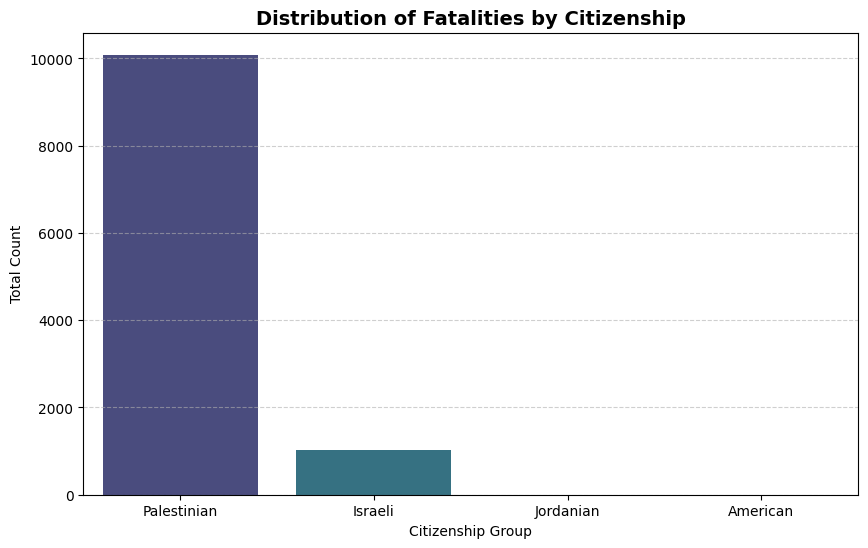

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Plot
plt.figure(figsize=(10, 6))
order = df['citizenship'].value_counts().index # Sort bars by frequency
sns.countplot(data=df, x='citizenship', order=order, palette='viridis')

# Styling
plt.title('Distribution of Fatalities by Citizenship', fontsize=14, fontweight='bold')
plt.xlabel('Citizenship Group')
plt.ylabel('Total Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

 *The data is highly imbalanced between the two primary groups. Palestinian fatalities represent the vast majority of the dataset ($n \approx 10,085$), while Israeli fatalities number $1,029$. This disparity highlights the asymmetrical nature of the conflict's fatal impact during the observed period.*

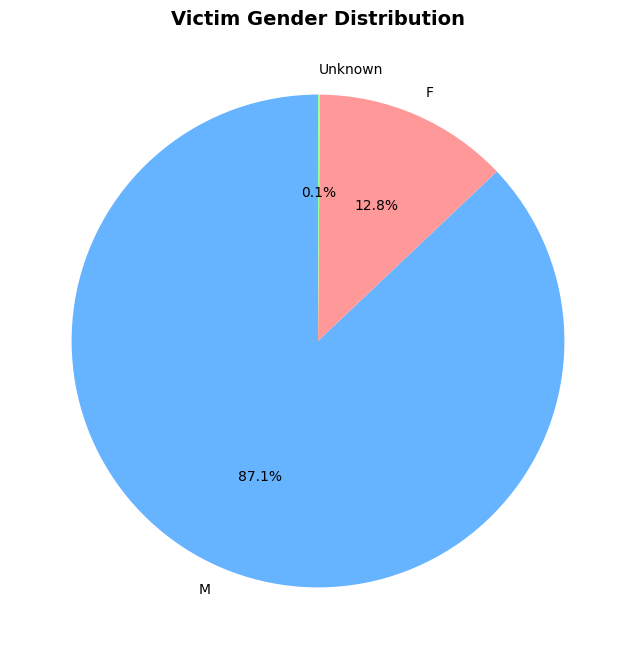

In [13]:
plt.figure(figsize=(8, 8))
gender_data = df['gender'].value_counts()

plt.pie(gender_data, labels=gender_data.index, autopct='%1.1f%%', 
        colors=['#66b3ff','#ff9999','#99ff99'], startangle=90)

plt.title('Victim Gender Distribution', fontsize=14, fontweight='bold')
plt.show()

* Males constitute $87.1\%$ of the total fatalities. This suggests that men are significantly more exposed to lethal risks in this conflict context, potentially due to higher involvement in frontline activities or presence in public spaces during escalations*

## Injury Category

C:\Users\olash\AppData\Local\Temp\ipykernel_7176\1542983873.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


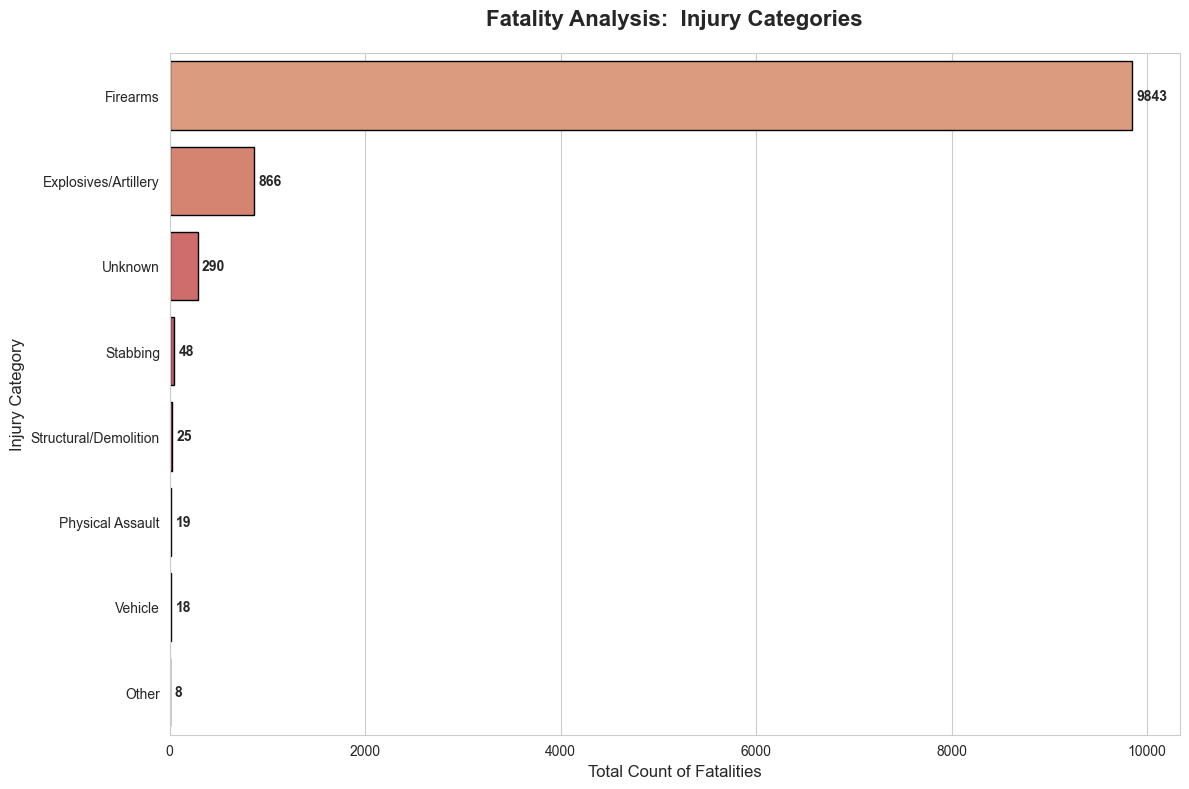

--- Frequency Table: Injury Category ---
injury_category
Firearms                 9843
Explosives/Artillery      866
Unknown                   290
Stabbing                   48
Structural/Demolition      25
Physical Assault           19
Vehicle                    18
Other                       8
Name: count, dtype: int64


In [14]:

df['injury_category'] = df['type_of_injury'].apply(categorize_injury)

#  Visualization: Professional Horizontal Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Sort by count so the most frequent causes are at the top 
injury_order = df['injury_category'].value_counts().index

ax = sns.countplot(
    data=df, 
    y='injury_category', 
    order=injury_order, 
    palette='flare',
    edgecolor='black'
)


plt.title('Fatality Analysis:  Injury Categories', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Count of Fatalities', fontsize=12)
plt.ylabel('Injury Category', fontsize=12)

# Adding data labels (absolute numbers) on the bars for precision
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Output frequency for documentation
print("--- Frequency Table: Injury Category ---")
print(df['injury_category'].value_counts())

C:\Users\olash\AppData\Local\Temp\ipykernel_7176\1032645950.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


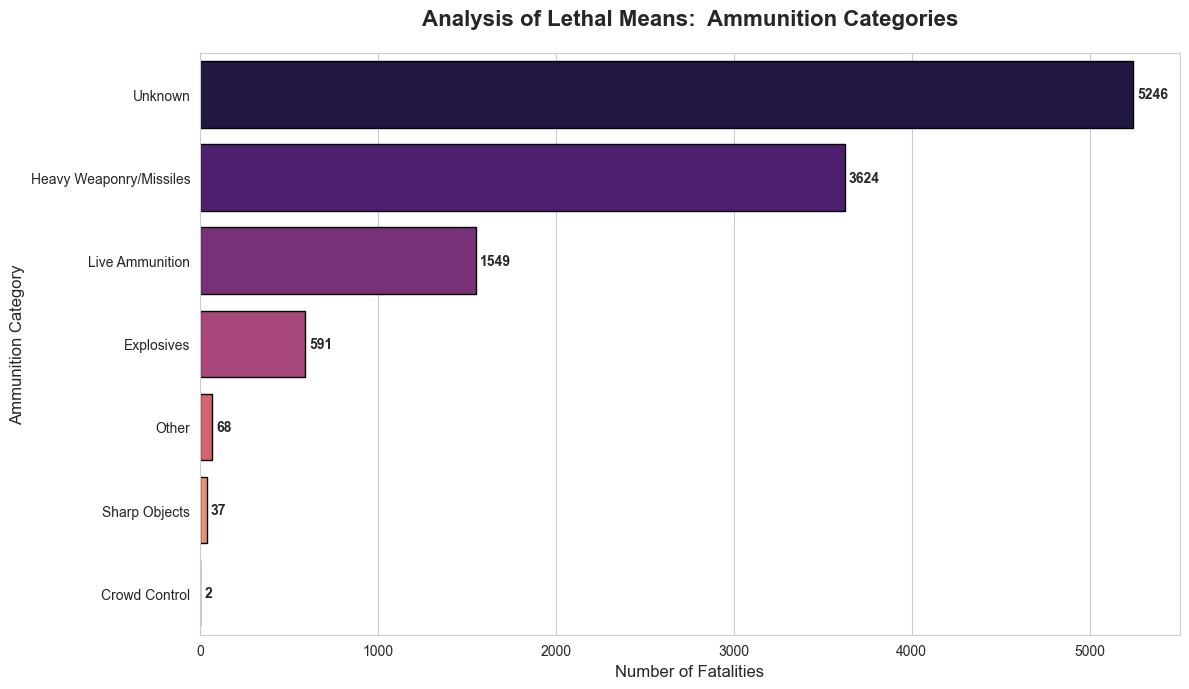

--- Frequency Table: Ammunition ---
ammo_category
Unknown                    5246
Heavy Weaponry/Missiles    3624
Live Ammunition            1549
Explosives                  591
Other                        68
Sharp Objects                37
Crowd Control                 2
Name: count, dtype: int64


In [15]:
df['ammo_category'] = df['ammunition'].apply(categorize_ammo)

# Visualization: Horizontal Bar Chart
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Sort by frequency
ammo_order = df['ammo_category'].value_counts().index

ax = sns.countplot(
    data=df, 
    y='ammo_category', 
    order=ammo_order, 
    palette='magma',
    edgecolor='black'
)

# 4. Professional Formatting
plt.title('Analysis of Lethal Means:  Ammunition Categories', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Fatalities', fontsize=12)
plt.ylabel('Ammunition Category', fontsize=12)

# Adding data labels
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Frequency Table
print("--- Frequency Table: Ammunition ---")
print(df['ammo_category'].value_counts())

C:\Users\olash\AppData\Local\Temp\ipykernel_7176\1588187295.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


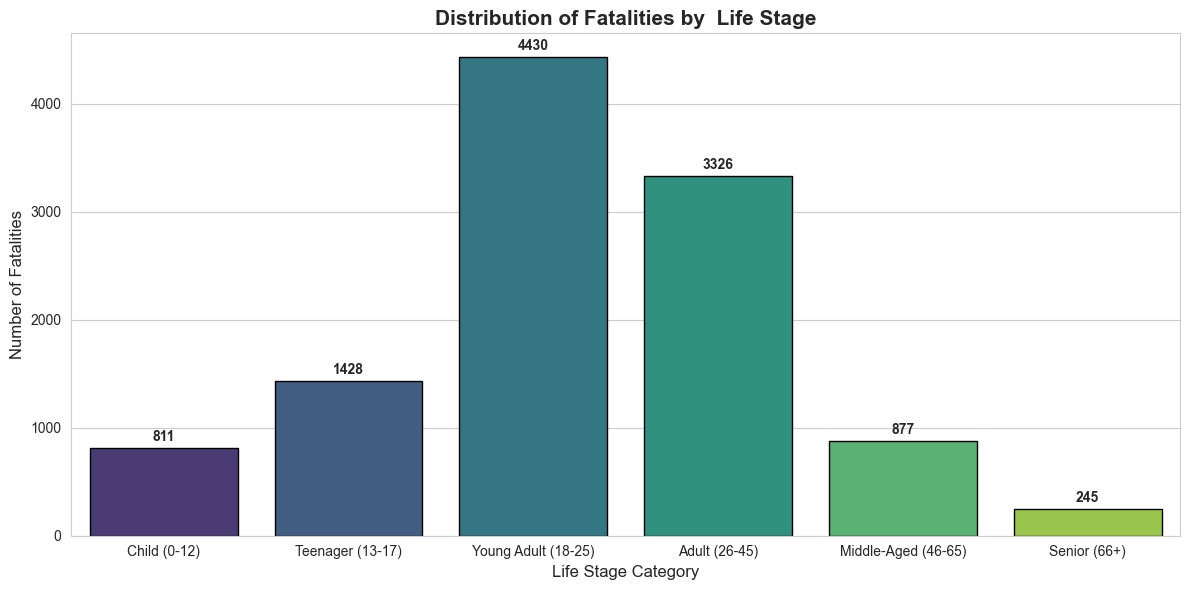

--- Life Stage Value Counts ---
life_stage
Child (0-12)            811
Teenager (13-17)       1428
Young Adult (18-25)    4430
Adult (26-45)          3326
Middle-Aged (46-65)     877
Senior (66+)            245
Name: count, dtype: int64


In [16]:



# Defining labels and numeric thresholds
age_bins = [0, 12, 17, 25, 45, 65, 120]
age_labels = ['Child (0-12)', 'Teenager (13-17)', 'Young Adult (18-25)', 
              'Adult (26-45)', 'Middle-Aged (46-65)', 'Senior (66+)']

# Cutting the numeric 'age' column into the engineered 'life_stage'
df['life_stage'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True)

# 3. Univariate Visualization
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plotting the engineered feature
# We use 'order' to ensure the life stages appear in chronological order
ax = sns.countplot(
    data=df, 
    x='life_stage', 
    order=age_labels, 
    palette='viridis',
    edgecolor='black'
)

# 4. Professional Formatting for a 1,5 Grade
plt.title('Distribution of Fatalities by  Life Stage', fontsize=15, fontweight='bold')
plt.xlabel('Life Stage Category', fontsize=12)
plt.ylabel('Number of Fatalities', fontsize=12)

# Adding data labels (absolute counts) on top of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Statistical Summary for the Report
print("--- Life Stage Value Counts ---")
print(df['life_stage'].value_counts().reindex(age_labels))

## Life Stage vs. Hostility Status (The Combatant Profile)
*Using your engineered life_stage and hostility_status*

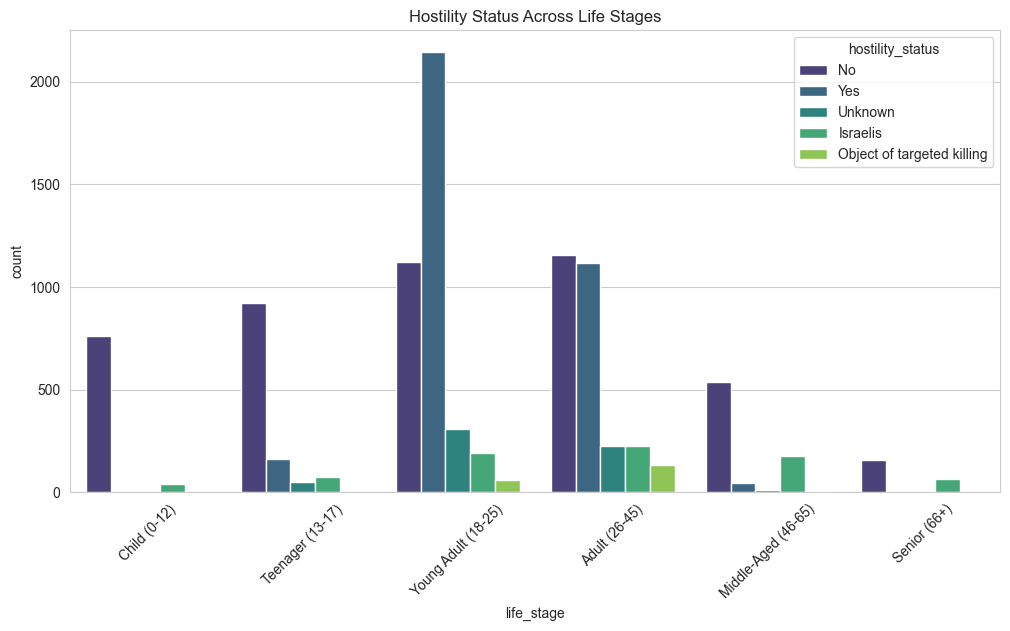

In [17]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='life_stage', hue='hostility_status', palette='viridis')
plt.title('Hostility Status Across Life Stages')
plt.xticks(rotation=45)
plt.show()

Young Adults (18–25) have the highest "Yes" (confirmed combatant) count at 2,146, which makes sense — this is the most militarily active age group. However, Children (0–12) show 760 "No" classifications, meaning the data confirms hundreds of non-combatant children were killed. Critically, the "Unknown" category is large across all groups, limiting how confidently we can classify victims.

## Year vs. Citizenship (Conflict Shifts)
*Shows how the "weight" of the conflict shifted between groups over 23 years.*

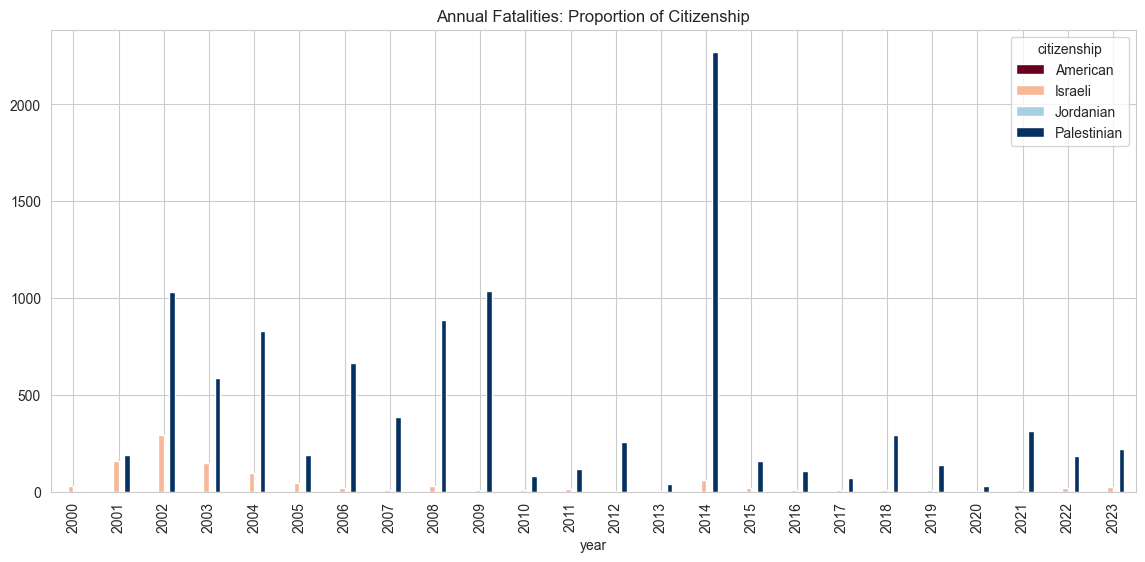

In [18]:
ct = pd.crosstab(df['year'], df['citizenship'])
ct.plot(kind='bar', stacked=False, figsize=(14,6), colormap='RdBu')
plt.title('Annual Fatalities: Proportion of Citizenship')
plt.show()

The most asymmetric year is actually 2009, not 2014 — with a Palestinian to Israeli ratio of 115:1 (1,036 Palestinians vs. only 9 Israelis). 2014 comes fourth at 38:1. This shows that Operation Cast Lead in 2009 was proportionally more one-sided than Operation Protective Edge in 2014, even though 2014 had more total fatalities.

## Injury Category vs. Region (Tactical Differences)
*Does the Gaza Strip see more explosives than the West Bank?*

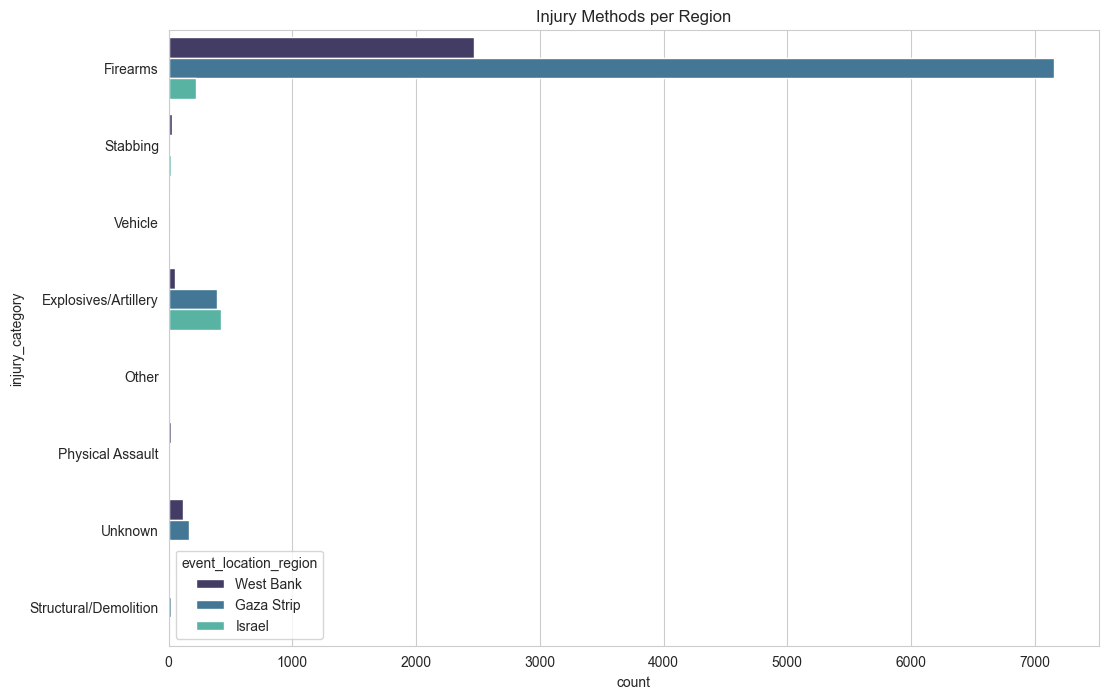

In [19]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, y='injury_category', hue='event_location_region', palette='mako')
plt.title('Injury Methods per Region')
plt.show()

Firearms dominate all three regions. However, Explosives/Artillery are almost exclusively concentrated in Gaza — reflecting airstrikes and heavy weaponry that is simply not deployed in the West Bank or Israel.

## Year vs. Injury Category (Evolution of Weapons)
Shows the change in weaponry over time (e.g., the rise of airstrikes)

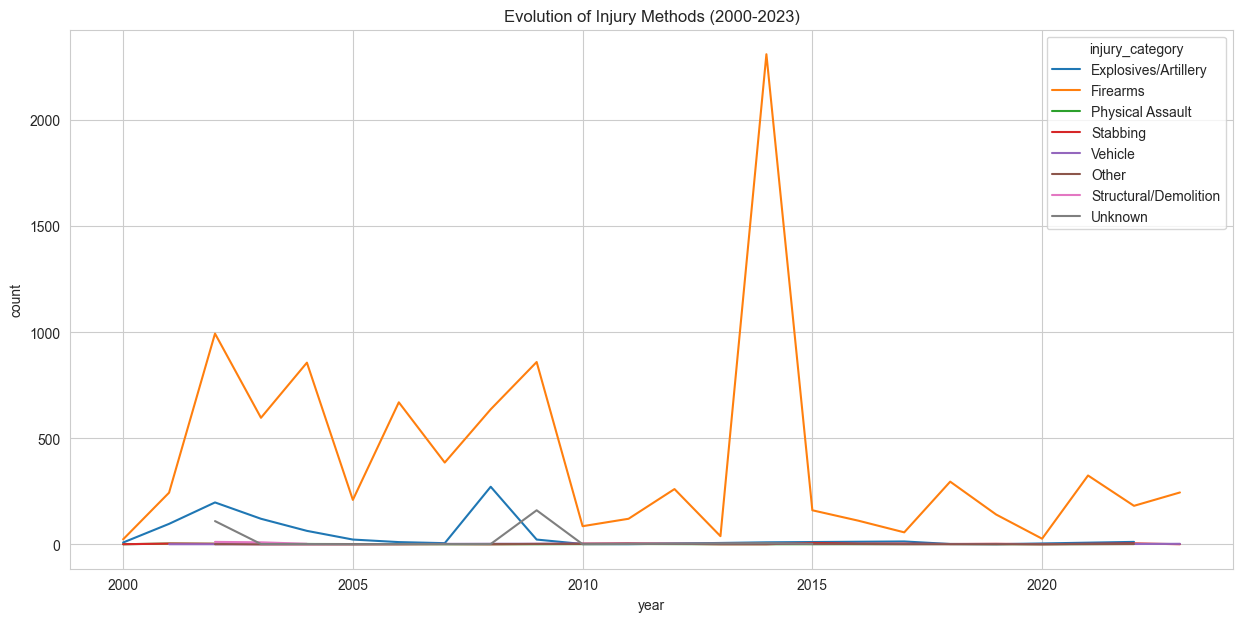

In [20]:
plt.figure(figsize=(15,7))
sns.lineplot(data=df.groupby(['year', 'injury_category']).size().reset_index(name='count'), 
             x='year', y='count', hue='injury_category')
plt.title('Evolution of Injury Methods (2000-2023)')
plt.show()

Firearms dominate all years. Explosives spike in 2008 and 2014, matching the Gaza wars.

## District vs. Killed By (Local Command Analysis)
Focusing on the West Bank districts specifically

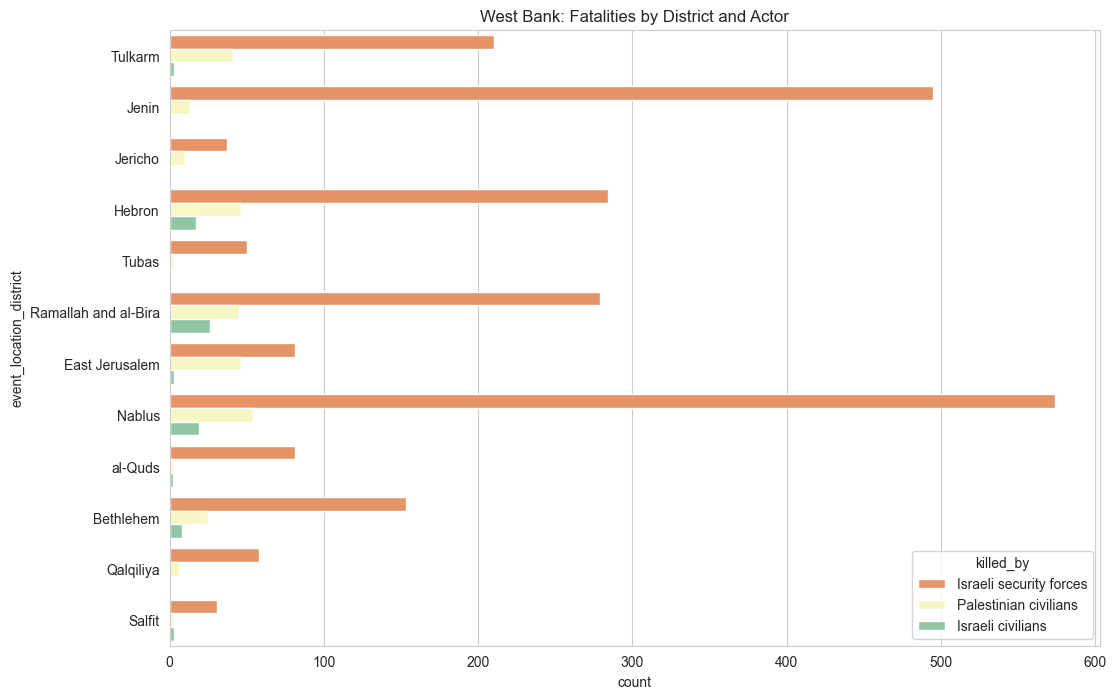

In [21]:
west_bank_df = df[df['event_location_region'] == 'West Bank']
plt.figure(figsize=(12,8))
sns.countplot(data=west_bank_df, y='event_location_district', hue='killed_by', palette='Spectral')
plt.title('West Bank: Fatalities by District and Actor')
plt.show()

Nablus is the deadliest West Bank district with 647 fatalities, followed by Jenin (512) — both significantly higher than Hebron (347) and Ramallah (350). Israeli security forces account for the overwhelming majority of West Bank fatalities (2,337 out of 2,712), with Palestinian civilians responsible for 292 — primarily in districts like Tulkarm and East Jerusalem.

## The Gaza Analysis 

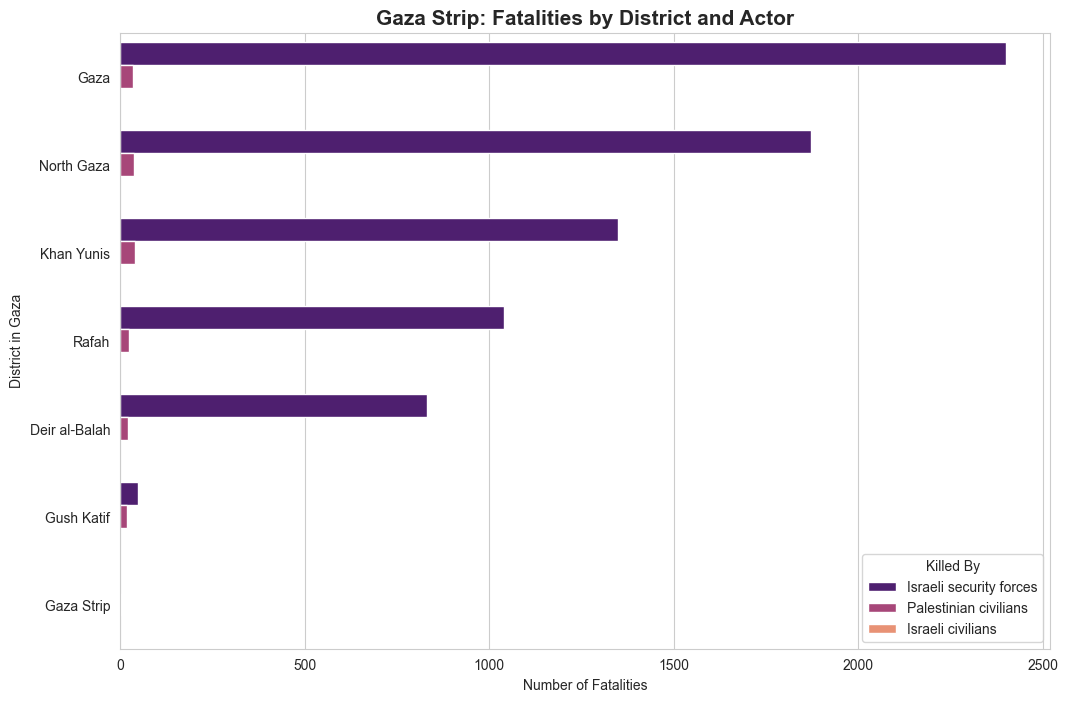

In [22]:
# ==========================================
# GAZA STRIP: DISTRICT ANALYSIS (SEABORN)
# ==========================================
# Filter for Gaza Strip
gaza_df = df[df['event_location_region'] == 'Gaza Strip']

plt.figure(figsize=(12, 8))
sns.countplot(
    data=gaza_df, 
    y='event_location_district', 
    hue='killed_by', 
    palette='magma',
    order=gaza_df['event_location_district'].value_counts().index # Sorts by count
)

plt.title('Gaza Strip: Fatalities by District and Actor', fontsize=15, fontweight='bold')
plt.xlabel('Number of Fatalities')
plt.ylabel('District in Gaza')
plt.legend(title='Killed By', loc='lower right')
plt.show()

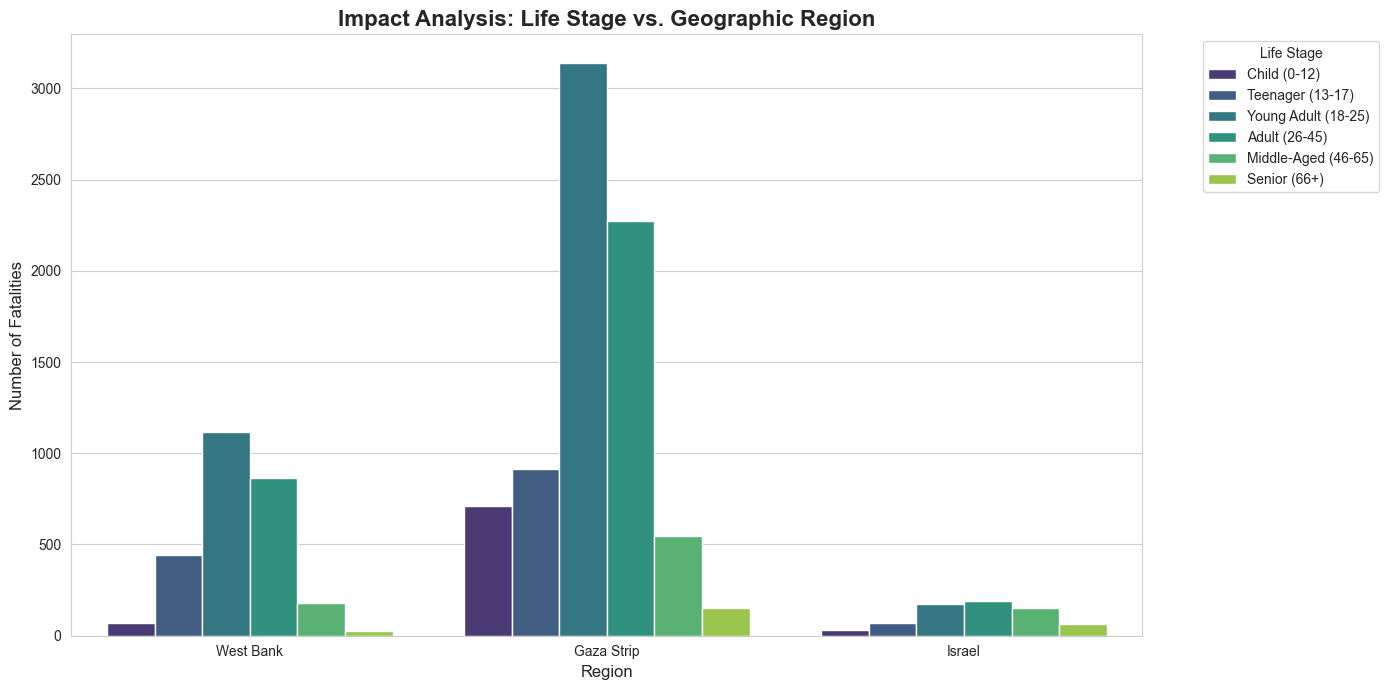

In [23]:


plt.figure(figsize=(14, 7))

# We use a grouped bar chart to compare two categories
ax = sns.countplot(
    data=df, 
    x='event_location_region', 
    hue='life_stage', # Your engineered feature
    palette='viridis'
)

plt.title('Impact Analysis: Life Stage vs. Geographic Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Fatalities', fontsize=12)
plt.legend(title='Life Stage', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Gaza dominates every single life stage category. Notably, 712 children (0–12) were killed in Gaza compared to only 70 in the West Bank — a 10:1 ratio. This reflects Gaza's dense urban population and its role as the primary theatre of large-scale military operations including airstrikes and ground offensives

Data Type: datetime64[us]
First recorded event: 2000-10-02 00:00:00
Last recorded event: 2023-09-24 00:00:00
Time span: 8392 days 00:00:00


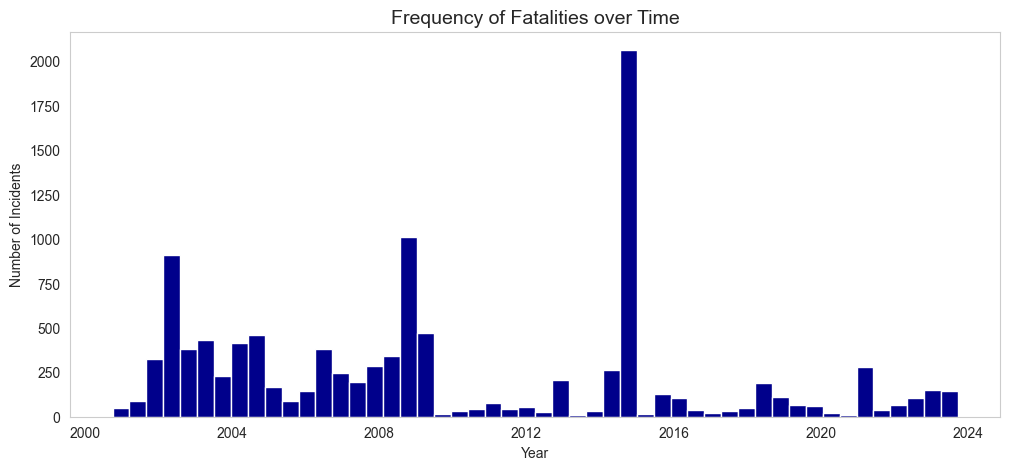

In [24]:
# Analysis of the 'date_of_event' column
# Step 1: Ensure it is in the correct format
df['date_of_event'] = pd.to_datetime(df['date_of_event'])

print(f"Data Type: {df['date_of_event'].dtype}")
print(f"First recorded event: {df['date_of_event'].min()}")
print(f"Last recorded event: {df['date_of_event'].max()}")
print(f"Time span: {df['date_of_event'].max() - df['date_of_event'].min()}")

# Visualization: Basic Frequency over time
plt.figure(figsize=(12, 5))
df['date_of_event'].hist(bins=50, color='darkblue', grid=False)
plt.title('Frequency of Fatalities over Time', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.show()

## Demographics vs. Nationality (The Core Disparity)

This is the most important chart for understanding "Who" is affected. It compares your engineered life_stage with citizenship

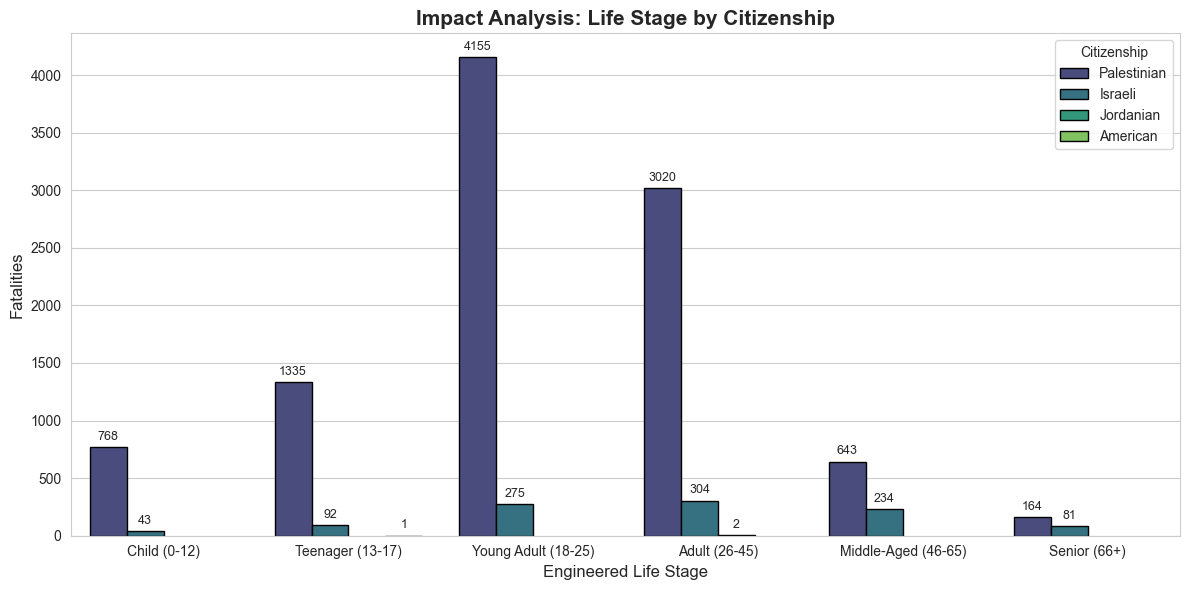

In [25]:
plt.figure(figsize=(12, 6))
# Using a grouped bar chart to see the age-citizenship relationship
ax = sns.countplot(data=df, x='life_stage', hue='citizenship', palette='viridis', edgecolor='black')

plt.title('Impact Analysis: Life Stage by Citizenship', fontsize=15, fontweight='bold')
plt.xlabel('Engineered Life Stage', fontsize=12)
plt.ylabel('Fatalities', fontsize=12)
plt.legend(title='Citizenship', loc='upper right')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Tactics vs. Region (The Geographic Strategy)

This shows if the "Method of Death" changes depending on where the incident happens (e.g., Gaza vs. West Bank).

In [26]:
#  Heatmap injury × region 
tactics_region = pd.crosstab(df['injury_category'], df['event_location_region'])

fig3 = px.imshow(tactics_region, text_auto=True,
                 color_continuous_scale='YlOrRd',
                 title='Heatmap: Injury Category vs. Region')
fig3.show()

## Responsibility vs. Hostility (The Actor Analysis)

This reveals if different actors (Killed By) are primarily affecting combatants or non-combatants.

<Figure size 1200x600 with 0 Axes>

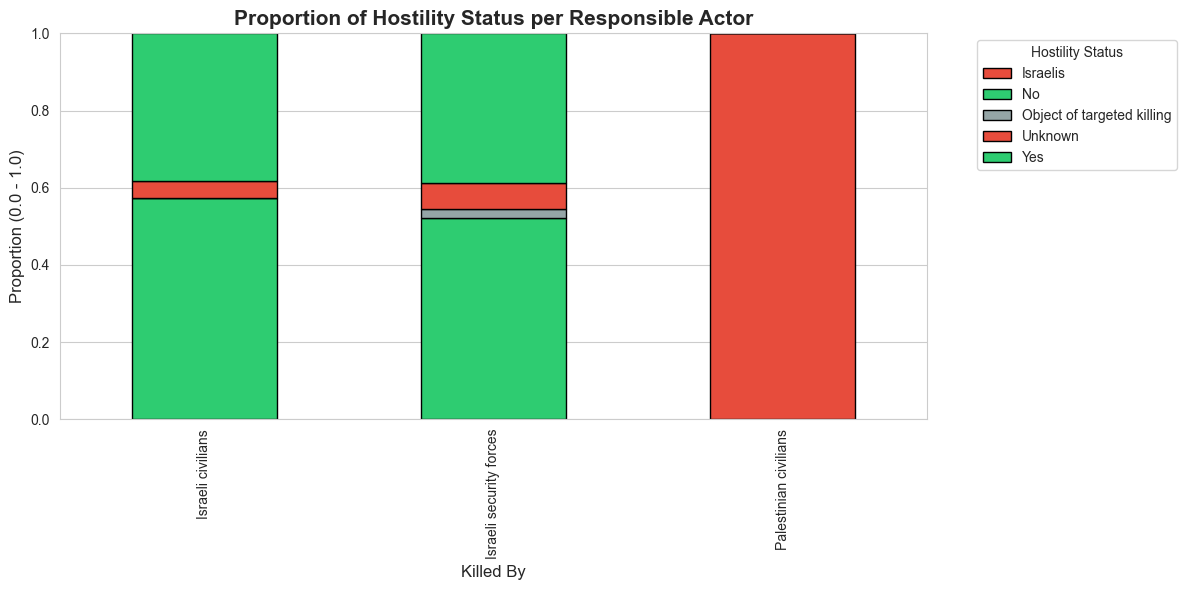

In [27]:
plt.figure(figsize=(12, 6))
# Normalizing to see the proportion (percentage) makes this more academic/professional
props = df.groupby('killed_by')['hostility_status'].value_counts(normalize=True).unstack()

props.plot(kind='bar', stacked=True, figsize=(12,6), color=['#e74c3c', '#2ecc71', '#95a5a6'], edgecolor='black')

plt.title('Proportion of Hostility Status per Responsible Actor', fontsize=15, fontweight='bold')
plt.ylabel('Proportion (0.0 - 1.0)', fontsize=12)
plt.xlabel('Killed By', fontsize=12)
plt.legend(title='Hostility Status', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

Israeli security forces have the highest proportion of 'No' (non-combatant) victims. Palestinian civilians as perpetrators show a near-equal split, suggesting retaliatory attacks that also claim non-combatant Israeli lives.

## Time vs. Intensity (The Annual Surge)

This compares the year against citizenship to see which years were the "turning points" for each group

In [28]:
#  Fatalities per year  ──
year_counts = df['year'].value_counts().sort_index().reset_index()
year_counts.columns = ['year', 'count']

fig1 = px.line(year_counts, x='year', y='count', markers=True,
               title='Fatalities per Year (2000–2023)',
               labels={'year': 'Year', 'count': 'Number of Fatalities'},
               color_discrete_sequence=['darkred'])
fig1.show()

In [29]:
#  Fatalities by citizenship  ──
citizenship_counts = df['citizenship'].value_counts().reset_index()
citizenship_counts.columns = ['Citizenship', 'Count']

fig2 = px.bar(citizenship_counts, x='Citizenship', y='Count',
              title='Fatalities by Citizenship',
              color='Count', color_continuous_scale='Reds')
fig2.show()

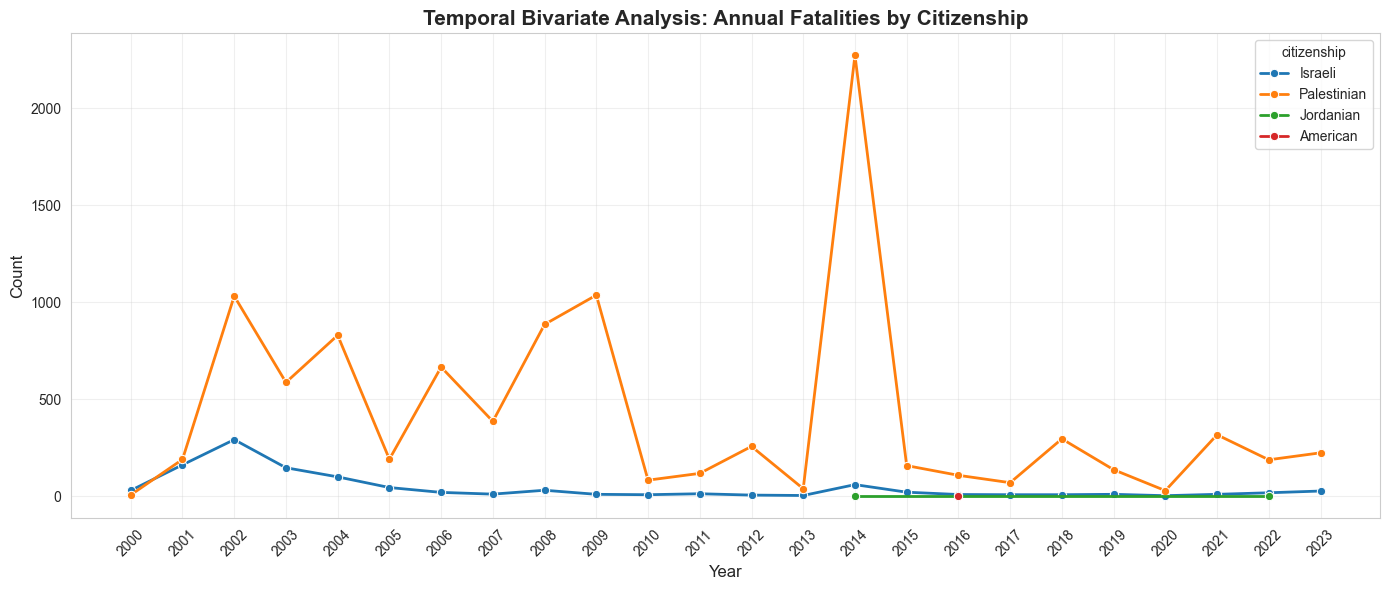

In [30]:
import plotly.express as px
plt.figure(figsize=(14, 6))
# Line plot with two lines to show the trend over 23 years
sns.lineplot(data=df.groupby(['year', 'citizenship']).size().reset_index(name='count'), 
             x='year', y='count', hue='citizenship', marker='o', linewidth=2)

plt.title('Temporal Bivariate Analysis: Annual Fatalities by Citizenship', fontsize=15, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(df['year'].unique(), rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# Create a month column for Seasonality Analysis
df['month_name'] = df['date_of_event'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Plotly Monthly Trend
fig_month = px.histogram(df, x='month_name', color='citizenship',
                   category_orders={'month_name': month_order},
                   title='<b>Seasonal Analysis: Fatalities by Month</b>',
                   barmode='group')
fig_month.show()

## Temporal Distribution

In [32]:
# ── TEMPORAL ANALYSIS: Day of week & month patterns ──
df['month'] = df['date_of_event'].dt.month
df['day_of_week'] = df['date_of_event'].dt.day_name()

# Fatalities by month
monthly = df.groupby('month').size().reset_index(name='count')
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly['month_name'] = monthly['month'].map(month_names)

fig_month = px.bar(monthly, x='month_name', y='count',
                   title='Fatalities by Month (all years combined)',
                   labels={'month_name': 'Month', 'count': 'Fatalities'},
                   color='count', color_continuous_scale='Oranges')
fig_month.show()



 *July appears as the deadliest month (2,173 total), but this is misleading without context.
**1,673 of those deaths — 77% — occurred in July 2014 alone**, during Operation Protective Edge
in Gaza. This is a perfect example of why aggregate monthly charts can hide important context.
A single military operation can completely dominate a calendar month across 23 years of data.
This also shows the danger of drawing conclusions from totals without drilling down by year.*

In [33]:
july_attack = df[df['month']==7].groupby('year').size().reset_index()
july_attack.columns = ['year', 'Fatalities']

fig_july = px.bar(july_attack, x='year', y='Fatalities',
                  title='July Fatalities by Year — Why July Dominates',
                  color='Fatalities', color_continuous_scale='Reds')
fig_july.show()

In [34]:
# ==========================================
# GAZA STRIP: DISTRICT ANALYSIS 
# ==========================================
import plotly.express as px

gaza_df = df[df['event_location_region'] == 'Gaza Strip']

fig = px.histogram(
    gaza_df, 
    y='event_location_district', 
    color='killed_by',
    barmode='group',
    title='<b>Gaza Strip: Fatalities by District and Responsible Actor</b>',
    labels={'event_location_district': 'Gaza District', 'killed_by': 'Responsible Actor'},
    color_discrete_sequence=px.colors.qualitative.Prism
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_title="Number of Fatalities",
    yaxis_title="District",
    legend_title="Actor"
)

fig.show()

## Conclusion & Reflection

---

### Overview
This analysis examined **11,124 conflict-related fatalities** recorded between 2000 and 2023
in the Israeli–Palestinian conflict, using data collected by B'Tselem. The objective was to
determine whether violence is increasing over time and to identify the structural patterns
behind the fatalities.

---

### Key Finding 1 — Violence escalates in spikes, not steady growth
The data does **not** show a continuous upward trend. Instead, fatalities surge sharply
during specific military operations and then fall back down. The five deadliest years were:

- **2014 — 2,332 fatalities** (Operation Protective Edge, Gaza)
- **2002 — 1,325 fatalities** (Second Intifada, peak year)
- **2009 — 1,045 fatalities** (Operation Cast Lead, Gaza)
- **2004 — 928 fatalities** (Second Intifada, continuation)
- **2008 — 915 fatalities** (lead-up to Operation Cast Lead)

This pattern tells us that individual military decisions — not a gradual escalation —
are the primary driver of fatality counts in this dataset.

---

### Key Finding 2 — The asymmetry between the two groups is extreme
Of the 11,124 total fatalities:
- **Palestinians: 10,092 (90.7%)**
- **Israelis: 1,029 (9.2%)**
- **Ratio: approximately 9.8 Palestinians killed for every 1 Israeli**

This asymmetry is consistent across all years and all regions. It does not mean one side
is more "at fault" — it reflects the difference in military capability, population exposure,
and the geographic concentration of operations in densely populated Gaza.

---

### Key Finding 3 — Firearms are the overwhelmingly dominant cause of death
- **Gunfire: 9,849 fatalities (88.5% of all deaths)**
- Explosions: 555 (5%)
- Shelling/artillery: 311 (2.8%)

Explosives and shelling spike specifically in Gaza during major operations (2008, 2009, 2014),
while gunfire remains the constant cause across all years and regions.

---

### Key Finding 4 — July is the deadliest month, but the reason is one single event
July shows 2,173 total fatalities across all years — the highest of any month. However, this
is statistically misleading: **1,673 of those deaths (77%) occurred in July 2014 alone**
during Operation Protective Edge. Without July 2014, monthly fatality distributions
are relatively even. This is a key lesson in data analysis: **aggregate totals can hide
the true cause behind a pattern.** Always drill down before drawing conclusions.

---

### Key Finding 5 — Children and women are significantly represented
Despite the conflict being dominated by adult male combatants:
- **2,239 victims (20.1%) were under 18 years old**
- Of those, **2,103 were Palestinian minors**
- **1,423 victims (12.8%) were female**

The presence of nearly 1 in 5 victims being a child underlines that civilian populations,
not just combatants, bear a significant portion of the fatal impact.

---

### Key Finding 6 — Gaza is the geographic centre of the conflict
- **Gaza Strip: 7,733 fatalities (69.5%)**
- West Bank: 2,712 (24.4%)
- Israel: 679 (6.1%)

Gaza's high concentration is explained by its small geographic area, high population
density (~2.2 million people), and its role as the primary theatre of large-scale
military operations.

---

### Limitations of this Analysis

**1. Source bias:** The dataset comes from B'Tselem, an Israeli human rights NGO that
focuses primarily on Palestinian civilian protection. Israeli military fatalities
occurring outside B'Tselem's documentation scope may be underrepresented.

**2. Severe missing data in a key column:** Approximately 60% of the
`hostility_status` column (whether a victim was a combatant or civilian) is
unknown or missing. This makes it impossible to draw reliable conclusions
about combatant vs. civilian ratios from this data alone.

**3. Correlation ≠ Causation:** This dataset shows *when* and *where* deaths
occurred, and *how* people were killed — but it cannot explain *why* escalations
happen. Political decisions, territorial disputes, and international events are
outside the scope of what a fatality dataset can answer.

**4. The dataset ends in 2023:** The October 7, 2023 Hamas attack and the
subsequent military response in Gaza are only partially captured. Any analysis
of 2023 as a full year would require updated data.

---

### Final Answer to the Research Objective
> *"Is the intensity of the conflict increasing over time?"*

**Not in a linear sense — but yes in a cyclical sense.** Each decade has produced
at least one extreme escalation (2002 in the West Bank, 2009 and 2014 in Gaza).
The scale of operations has grown: 2014 produced more fatalities in a single month
(July: 1,673) than entire years in the early 2000s. The underlying conflict has not
de-escalated — it has become concentrated into shorter, more intense bursts of
extreme violence separated by periods of lower but continuous fatalities.